# EDA — PRDECT-ID Dataset
Notebook ini untuk *Exploratory Data Analysis* (EDA) pada dataset `PRDECT-ID Dataset.csv`.

Fokus:
- Audit kualitas data (missing values, duplikat, tipe data)
- Eksplorasi fitur numerik & kategorikal
- EDA teks ulasan (Bahasa Indonesia)
- Perbandingan metrik berdasarkan `Sentiment` & `Emotion`

Tanggal dibuat: 2026-06-01

In [1]:
# 1) Setup & Import Library
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seaborn opsional (visualisasi lebih enak)
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

# Scikit-learn opsional (TF-IDF / CountVectorizer)
try:
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.feature_selection import chi2
    HAS_SKLEARN = True
except Exception:
    CountVectorizer = None
    TfidfVectorizer = None
    chi2 = None
    HAS_SKLEARN = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 5)

if HAS_SEABORN:
    sns.set_theme(style="whitegrid")

print("seaborn:", HAS_SEABORN, "| sklearn:", HAS_SKLEARN)

seaborn: True | sklearn: True


## 2) Load CSV ke DataFrame
Notebook ini mengasumsikan file `PRDECT-ID Dataset.csv` ada di folder yang sama dengan notebook.

In [2]:
DATA_PATH = "PRDECT-ID Dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Tidak ketemu: {DATA_PATH}. Pastikan CSV ada di folder yang sama dengan notebook.")

# Coba beberapa encoding umum (dataset ulasan kadang bukan UTF-8 murni)
read_errors = []
for enc in ("utf-8", "utf-8-sig", "latin-1"):
    try:
        df = pd.read_csv(DATA_PATH, encoding=enc)
        used_encoding = enc
        break
    except Exception as e:
        read_errors.append((enc, str(e)))
else:
    raise RuntimeError("Gagal membaca CSV. Error per encoding: " + str(read_errors))

# Basic standardisasi kolom
df.columns = [c.strip() for c in df.columns]

print("Encoding dipakai:", used_encoding)
print("Shape:", df.shape)
df.head(5)

Encoding dipakai: utf-8
Shape: (5400, 11)


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G Handheld PC Android TV,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 ORIGINAL + BONUS,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing dengan yg lain.",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG 19V ORIGINAL,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. trimakasih pelapak ??,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG 19V ORIGINAL,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi dengan Baik",Positive,Happy


## 3) Quick Data Audit (shape, dtypes, missing, duplikat)

In [3]:
expected_cols = [
    "Category", "Product Name", "Location", "Price", "Overall Rating",
    "Number Sold", "Total Review", "Customer Rating", "Customer Review",
    "Sentiment", "Emotion",
]

print("Kolom ditemukan:", list(df.columns))
missing_expected = [c for c in expected_cols if c not in df.columns]
if missing_expected:
    print("WARNING: kolom expected tidak ada:", missing_expected)

display(df.head(3))

print("\nInfo:")
display(df.info())

print("\nDeskripsi (include=all):")
display(df.describe(include="all").T)

Kolom ditemukan: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G Handheld PC Android TV,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 ORIGINAL + BONUS,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing dengan yg lain.",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat",Positive,Happy



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


None


Deskripsi (include=all):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Category,5400,29,Computers and Laptops,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Name,5400,1308,Minigold Black Series Logam Mulia Koin Emas Mini 24 Karat 0.025 gram,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,5400,61,Jakarta Barat,1293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,5400.0,NaN,NaN,NaN,238696.133519,801633.71926,100.0,20000.0,59900.0,150000.0,15399000.0
Overall Rating,5400.0,NaN,NaN,NaN,4.854389,0.108259,4.1,4.8,4.9,4.9,5.0
Number Sold,5400.0,NaN,NaN,NaN,15961.951852,74201.913338,9.0,1630.0,3794.5,9707.0,1000000.0
Total Review,5400.0,NaN,NaN,NaN,2168.645556,2915.666035,4.0,576.0,1192.0,2582.0,24500.0
Customer Rating,5400.0,NaN,NaN,NaN,3.087037,1.766258,1.0,1.0,3.0,5.0,5.0
Customer Review,5400,5305,jelek,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sentiment,5400,2,Negative,2821,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,metric,value
0,n_rows,5400
1,n_cols,11
2,duplicate_rows,7
3,duplicate_customer_review,95
4,duplicate_product_location_price,4079


,missing_count,missing_pct
Category,0,0.0
Product Name,0,0.0
Location,0,0.0
Price,0,0.0
Overall Rating,0,0.0
Number Sold,0,0.0
Total Review,0,0.0
Customer Rating,0,0.0
Customer Review,0,0.0
Sentiment,0,0.0


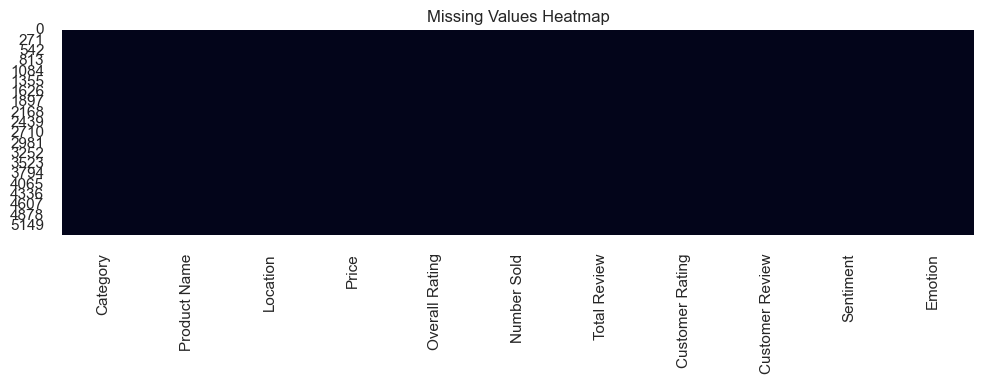

In [4]:
# Missing values
na_count = df.isna().sum()
na_pct = (na_count / len(df) * 100).round(2)
audit_missing = (
    pd.DataFrame({"missing_count": na_count, "missing_pct": na_pct})
      .sort_values(["missing_count", "missing_pct"], ascending=False)
)

# Duplikat
row_dupes = int(df.duplicated().sum())

subset_review = [c for c in ["Customer Review"] if c in df.columns]
review_dupes = int(df.duplicated(subset=subset_review).sum()) if subset_review else np.nan

# Duplikat produk + lokasi + harga (indikasi entri sama)
subset_prod = [c for c in ["Product Name", "Location", "Price"] if c in df.columns]
prod_dupes = int(df.duplicated(subset=subset_prod).sum()) if subset_prod else np.nan

quality_summary = pd.DataFrame(
    {
        "metric": [
            "n_rows", "n_cols", "duplicate_rows",
            "duplicate_customer_review", "duplicate_product_location_price",
        ],
        "value": [
            df.shape[0], df.shape[1], row_dupes,
            review_dupes, prod_dupes,
        ],
    }
)

display(quality_summary)
display(audit_missing)

if HAS_SEABORN:
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isna(), cbar=False)
    plt.title("Missing Values Heatmap")
    plt.tight_layout()
    plt.show()

## 4) Data Cleaning & Type Casting (angka, teks, label)
Kita buat `df_clean` terpisah agar data mentah (`df`) tetap aman.

In [5]:
def normalize_whitespace(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text


def to_numeric_series(s: pd.Series) -> pd.Series:
    # Jaga-jaga kalau ada pemisah ribuan / simbol lain
    s = s.astype(str).str.replace(r"[^0-9.\-]", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


df_clean = df.copy()

# Cast numerik
num_cols = ["Price", "Overall Rating", "Number Sold", "Total Review", "Customer Rating"]
for c in [x for x in num_cols if x in df_clean.columns]:
    df_clean[c] = to_numeric_series(df_clean[c])

# Bersihkan teks
text_cols = ["Category", "Product Name", "Location", "Customer Review", "Sentiment", "Emotion"]
for c in [x for x in text_cols if x in df_clean.columns]:
    df_clean[c] = df_clean[c].map(normalize_whitespace)

# Normalisasi label
if "Sentiment" in df_clean.columns:
    df_clean["Sentiment"] = df_clean["Sentiment"].str.title()
if "Emotion" in df_clean.columns:
    df_clean["Emotion"] = df_clean["Emotion"].str.title()

# Buang baris kosong total (opsional, minimal)
df_clean = df_clean.dropna(how="all").reset_index(drop=True)

print("Shape df_clean:", df_clean.shape)
display(df_clean.head(3))

display(df_clean[num_cols].describe().T if all(c in df_clean.columns for c in num_cols) else df_clean.describe().T)

Shape df_clean: (5400, 11)


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G Handheld PC Android TV,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 ORIGINAL + BONUS,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing dengan yg lain.",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat",Positive,Happy


,count,mean,std,min,25%,50%,75%,max
Price,5400.0,238696.133519,801633.719260,100.0,20000.0,59900.0,150000.0,15399000.0
Overall Rating,5400.0,4.854389,0.108259,4.1,4.8,4.9,4.9,5.0
Number Sold,5400.0,15961.951852,74201.913338,9.0,1630.0,3794.5,9707.0,1000000.0
Total Review,5400.0,2168.645556,2915.666035,4.0,576.0,1192.0,2582.0,24500.0
Customer Rating,5400.0,3.087037,1.766258,1.0,1.0,3.0,5.0,5.0


## 5) EDA Target Label: Distribusi Sentiment & Emotion

,count,pct
Sentiment,,
Negative,2821,52.24
Positive,2579,47.76


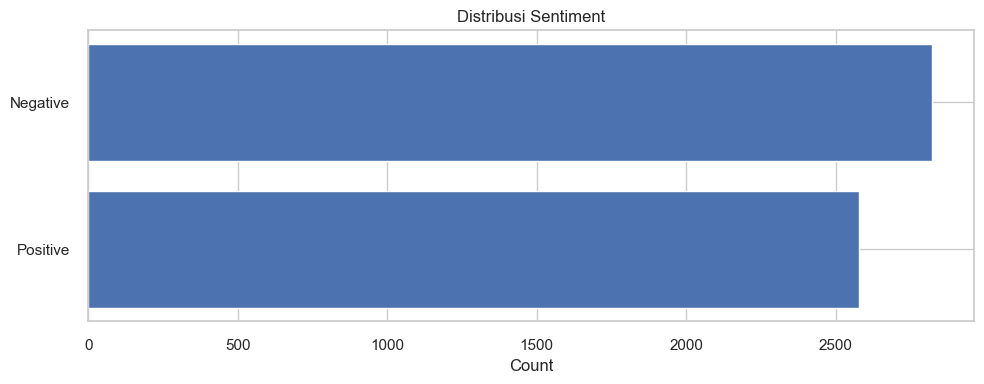

,count,pct
Emotion,,
Happy,1770,32.78
Sadness,1202,22.26
Fear,920,17.04
Love,809,14.98
Anger,699,12.94


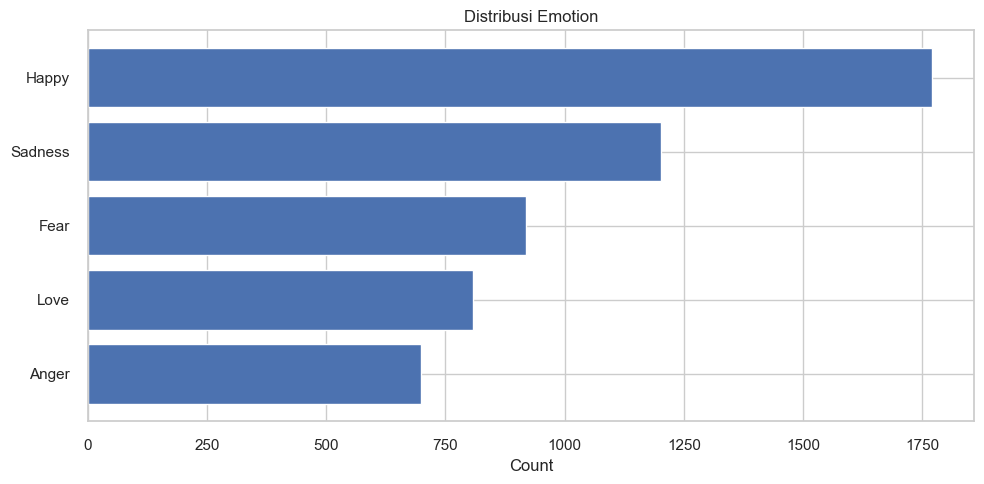

Emotion,Anger,Fear,Happy,Love,Sadness
Sentiment,,,,,
Negative,0.247784,0.326125,0.000000,0.000000,0.42609
Positive,0.000000,0.000000,0.686313,0.313687,0.00000


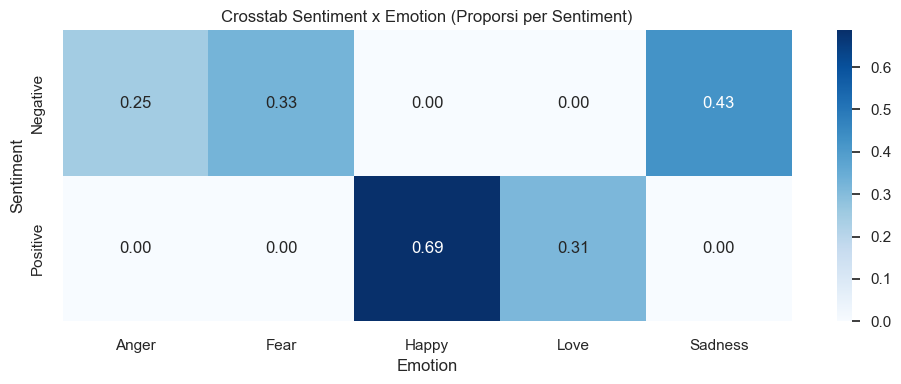

In [6]:
def plot_top_counts(series: pd.Series, title: str, top_n: int = 20):
    vc = series.value_counts(dropna=False).head(top_n)
    pct = (vc / vc.sum() * 100).round(2)
    display(pd.DataFrame({"count": vc, "pct": pct}))

    plt.figure(figsize=(10, max(4, int(top_n * 0.35))))
    plt.barh(vc.index.astype(str)[::-1], vc.values[::-1])
    plt.title(title)
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()


if "Sentiment" in df_clean.columns:
    plot_top_counts(df_clean["Sentiment"], "Distribusi Sentiment", top_n=10)

if "Emotion" in df_clean.columns:
    plot_top_counts(df_clean["Emotion"], "Distribusi Emotion", top_n=15)

if all(c in df_clean.columns for c in ["Sentiment", "Emotion"]):
    ct = pd.crosstab(df_clean["Sentiment"], df_clean["Emotion"], normalize="index")
    display(ct)

    if HAS_SEABORN:
        plt.figure(figsize=(10, 4))
        sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
        plt.title("Crosstab Sentiment x Emotion (Proporsi per Sentiment)")
        plt.tight_layout()
        plt.show()

## 6) EDA Kategorikal: Category, Location (top-N & proporsi)

,count,pct
Category,,
Computers and Laptops,200,6.67
Toys and Hobbies,200,6.67
Food and Drink,200,6.67
Office & Stationery,200,6.67
Automotive,200,6.67
Animal Care,200,6.67
Body Care,200,6.67
Party Supplies and Craft,200,6.67
Carpentry,200,6.67


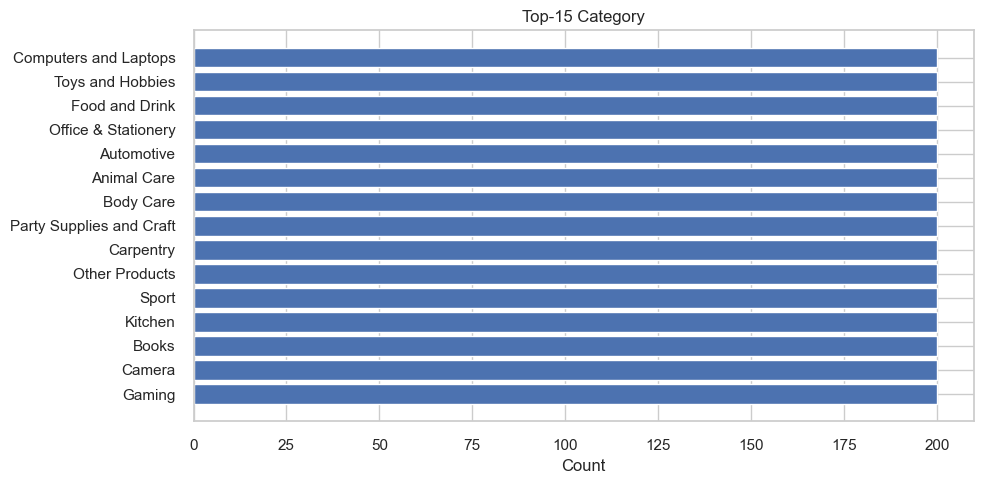

,count,pct
Location,,
Jakarta Barat,1295,25.51
Jakarta Utara,877,17.27
Jakarta Pusat,472,9.30
Kota Tangerang,416,8.19
Kab. Tangerang,395,7.78
Jakarta Timur,372,7.33
Jakarta Selatan,297,5.85
Kota Tangerang Selatan,249,4.90
Kota Bekasi,189,3.72


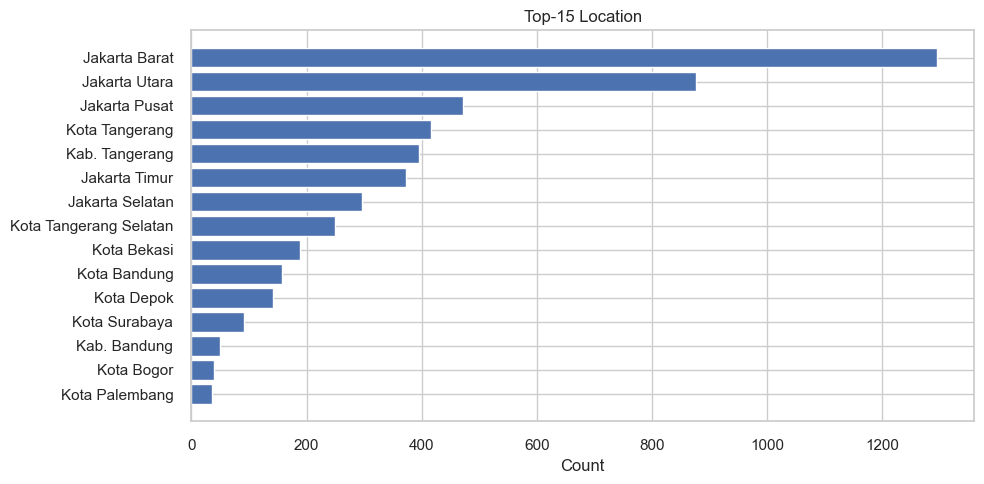

Jumlah lokasi unik (asli): 56
Jumlah lokasi unik (grouped): 29


,count,pct
Location_grouped,,
Jakarta Barat,1295,25.15
Jakarta Utara,877,17.03
Jakarta Pusat,472,9.17
Kota Tangerang,416,8.08
Kab. Tangerang,395,7.67
Jakarta Timur,372,7.22
Jakarta Selatan,297,5.77
Kota Tangerang Selatan,249,4.84
Kota Bekasi,189,3.67


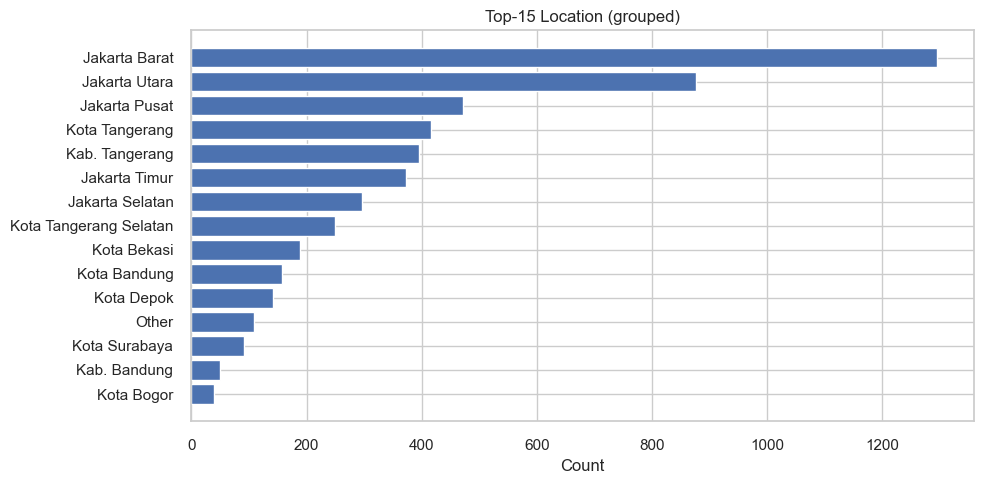

In [7]:
TOP_N = 15

if "Category" in df_clean.columns:
    plot_top_counts(df_clean["Category"], f"Top-{TOP_N} Category", top_n=TOP_N)

if "Location" in df_clean.columns:
    plot_top_counts(df_clean["Location"], f"Top-{TOP_N} Location", top_n=TOP_N)

# (Opsional) mapping lokasi jarang ke 'Other' agar plot lebih jelas
if "Location" in df_clean.columns:
    loc_counts = df_clean["Location"].value_counts()
    rare_locs = set(loc_counts[loc_counts < 10].index)  # threshold bisa kamu ubah
    df_clean["Location_grouped"] = df_clean["Location"].apply(lambda x: "Other" if x in rare_locs else x)
    print("Jumlah lokasi unik (asli):", df_clean["Location"].nunique())
    print("Jumlah lokasi unik (grouped):", df_clean["Location_grouped"].nunique())
    plot_top_counts(df_clean["Location_grouped"], f"Top-{TOP_N} Location (grouped)", top_n=TOP_N)

## 7) EDA Numerik: Price, Overall Rating, Number Sold, Total Review, Customer Rating
Termasuk versi log-transform $x' = \log(1 + x)$ untuk variabel yang sangat skew.

,count,mean,std,min,25%,50%,75%,max
Price,5400.0,238696.133519,801633.719260,100.0,20000.0,59900.0,150000.0,15399000.0
Overall Rating,5400.0,4.854389,0.108259,4.1,4.8,4.9,4.9,5.0
Number Sold,5400.0,15961.951852,74201.913338,9.0,1630.0,3794.5,9707.0,1000000.0
Total Review,5400.0,2168.645556,2915.666035,4.0,576.0,1192.0,2582.0,24500.0
Customer Rating,5400.0,3.087037,1.766258,1.0,1.0,3.0,5.0,5.0


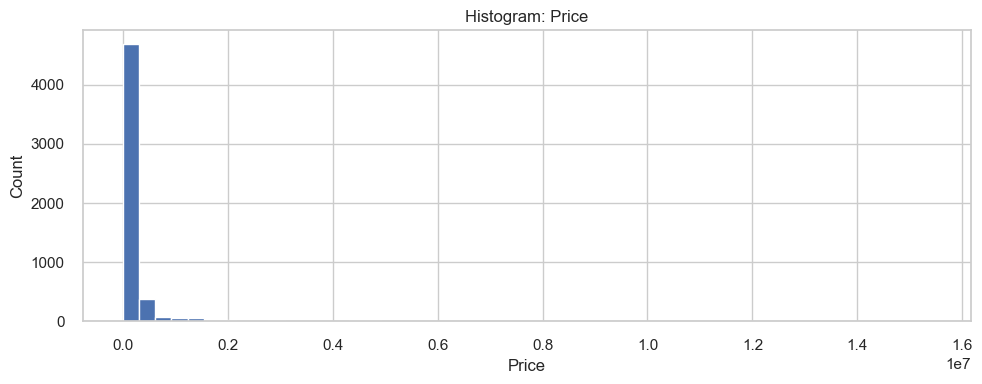

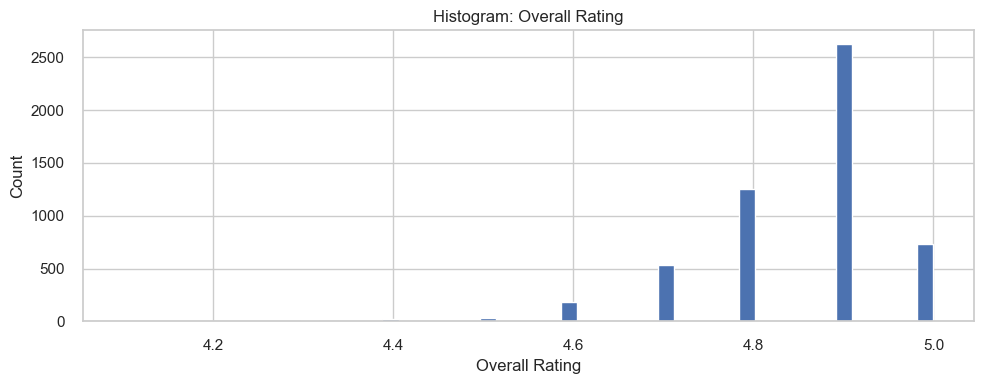

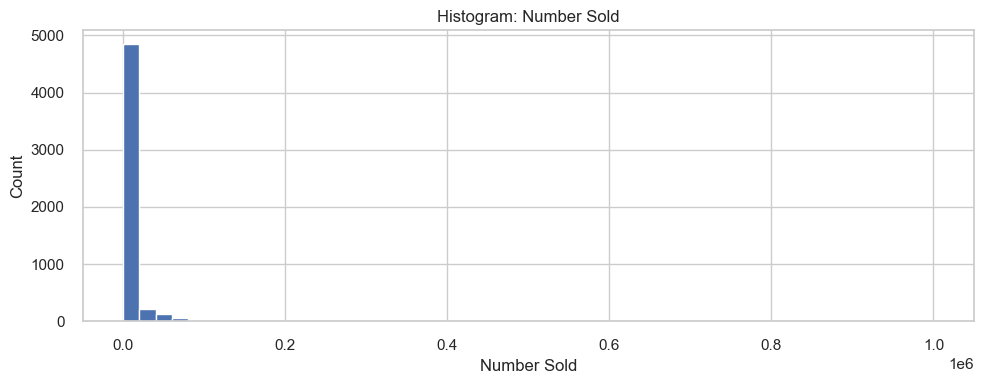

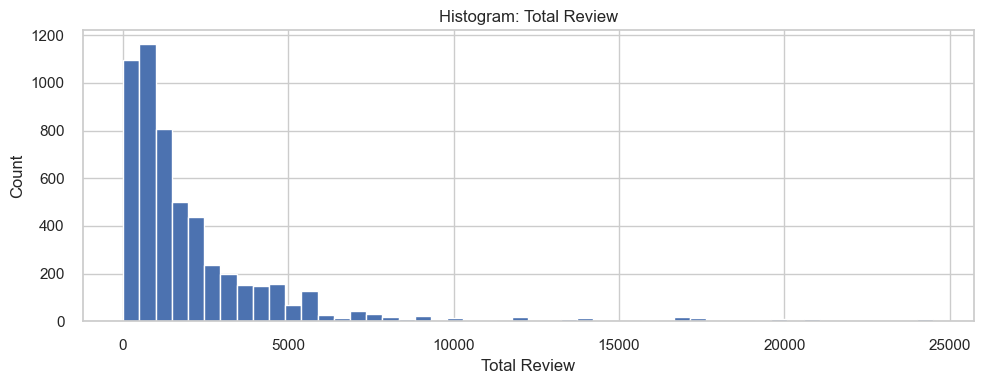

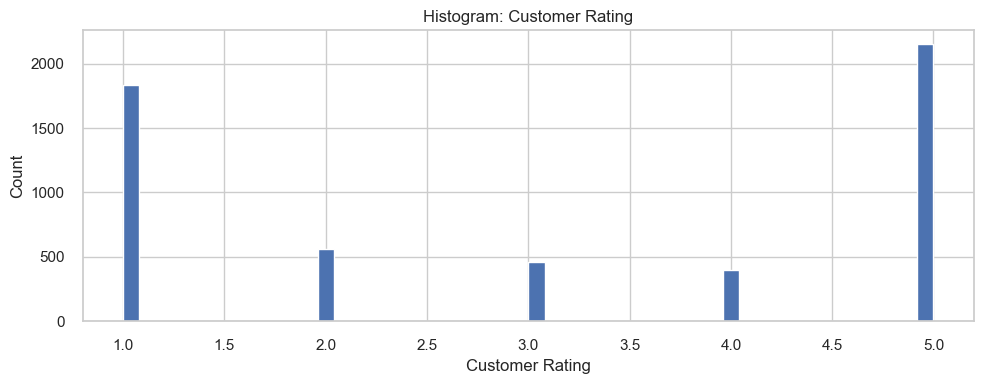

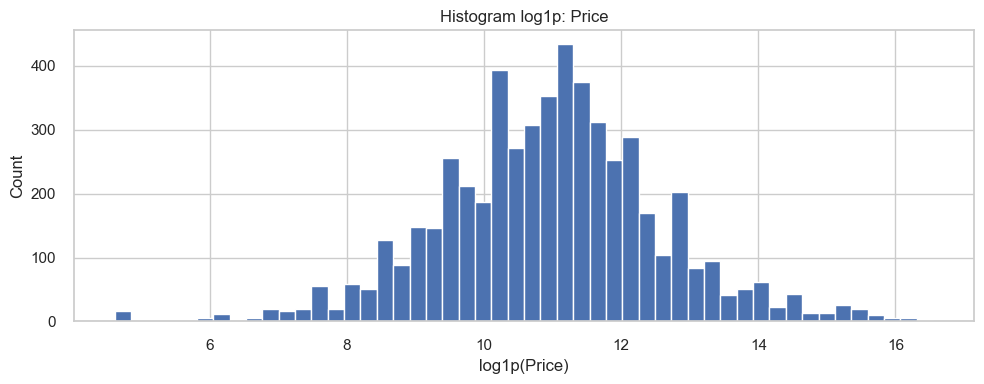

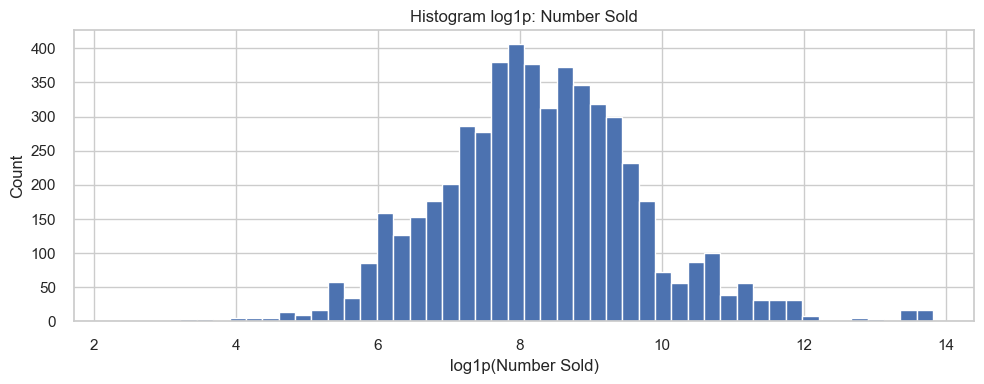

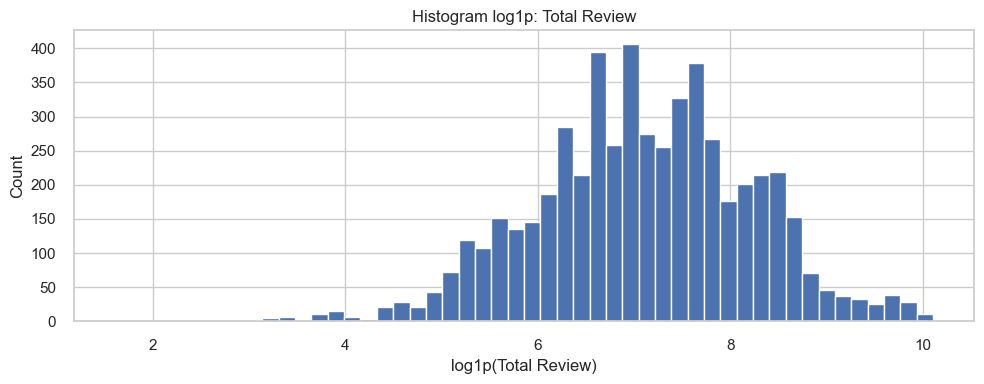

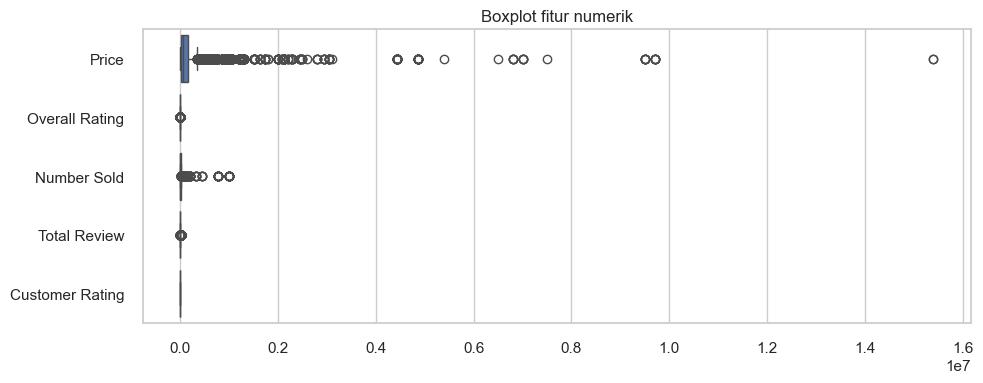

In [8]:
numeric_cols = [c for c in ["Price", "Overall Rating", "Number Sold", "Total Review", "Customer Rating"] if c in df_clean.columns]
display(df_clean[numeric_cols].describe().T)

# Histogram tiap kolom numerik
for c in numeric_cols:
    x = df_clean[c].dropna()
    plt.figure(figsize=(10, 4))
    plt.hist(x, bins=50)
    plt.title(f"Histogram: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Log-transform untuk yang skew
skew_cols = [c for c in ["Price", "Number Sold", "Total Review"] if c in df_clean.columns]
for c in skew_cols:
    x = df_clean[c].dropna()
    x_log = np.log1p(x)
    plt.figure(figsize=(10, 4))
    plt.hist(x_log, bins=50)
    plt.title(f"Histogram log1p: {c}")
    plt.xlabel(f"log1p({c})")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Boxplot outlier
if HAS_SEABORN and numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_clean[numeric_cols], orient="h")
    plt.title("Boxplot fitur numerik")
    plt.tight_layout()
    plt.show()

## 8) Analisis Grup: Rata-rata/Median metrik per Category & Location

Price            Overall Rating         \
                              mean     median           mean median   
Category                                                              
Tour and Travel        1858960.000  1270000.0        4.96625    5.0   
Precious Metal         1692653.750   314600.0        5.00000    5.0   
Electronics             554199.665   176000.0        4.84250    4.9   
Phones and Tablets     1063574.950   175000.0        4.82550    4.8   
Mother and Baby         347670.345   147120.0        4.90950    4.9   
Computers and Laptops   401509.345   126440.0        4.86800    4.9   
Gaming                  434088.635   125000.0        4.84250    4.8   
Kitchen                 214853.970   119000.0        4.87450    4.9   
Books                   129937.000    99000.0        4.90500    4.9   
Men's Fashion           140427.415    93000.0        4.81750    4.8   

                      Customer Rating        Number Sold         Total Review  \
                                 mean median        mean  median         mean   
Category                                                                        
Tour and Travel                 5.000    5.0    1957.650  1491.0      368.275   
Precious Metal                  5.000    5.0    3447.150  1316.0      505.175   
Electronics                     3.180    3.0    6118.710  2129.0     1997.415   
Phones and Tablets              3.135    3.0    9215.870  5770.0     3883.820   
Mother and Baby                 3.150    3.5    6557.600  4316.5     1966.660   
Computers and Laptops           2.630    1.0    6436.930  4826.0     2655.355   
Gaming                          3.395    3.5    1856.905   843.0      591.985   
Kitchen                         3.165    3.0    9258.610  3772.0     2534.525   
Books                           3.285    3.0    3553.875   955.0      584.190   
Men's Fashion                   3.370    3.0    5148.775  1849.0     1522.785   

                               
                       median  
Category                       
Tour and Travel         305.0  
Precious Metal          549.0  
Electronics             731.0  
Phones and Tablets     2533.0  
Mother and Baby        1713.0  
Computers and Laptops  2281.0  
Gaming                  404.5  
Kitchen                1775.0  
Books                   440.0  
Men's Fashion           706.0

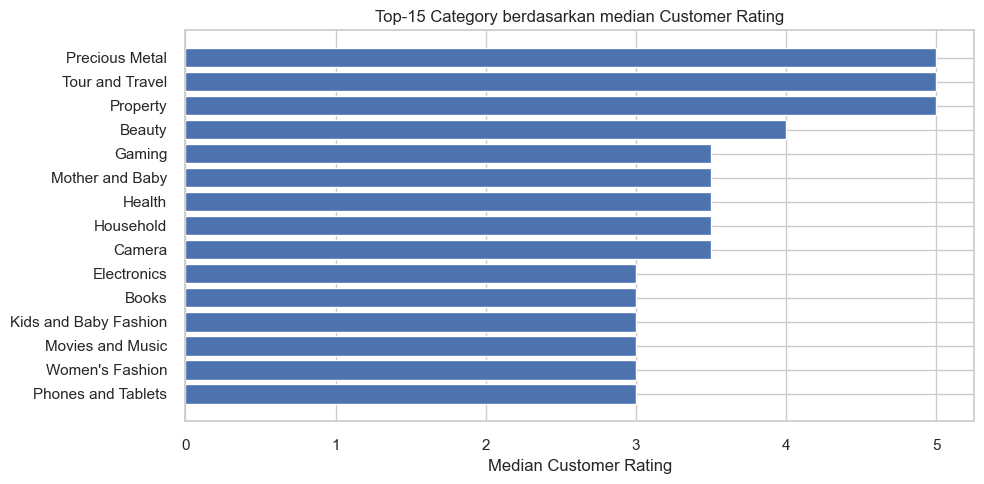

,Price,Overall Rating,Customer Rating,Number Sold,Total Review
Location_grouped,,,,,
Bandung,50000.0,4.9,5.0,2184.0,598.5
Kab. Kediri,27000.0,4.8,5.0,10700.0,1804.0
Kab. Tulungagung,299900.0,4.4,5.0,326.0,213.0
Kota Surabaya,63000.0,4.9,5.0,6133.5,1208.0
Jakarta Selatan,78000.0,4.9,4.0,3737.0,1459.0
Kab. Serang,122500.0,4.9,4.0,8723.5,4581.5
Kab. Pemalang,15900.0,4.8,4.0,2938.0,737.0
Other,62900.0,4.9,4.0,2242.0,548.0
Kota Tangerang Selatan,117500.0,4.9,4.0,3413.0,1057.0


In [9]:
metric_cols = [c for c in ["Price", "Overall Rating", "Customer Rating", "Number Sold", "Total Review"] if c in df_clean.columns]

if "Category" in df_clean.columns and metric_cols:
    grp_cat = df_clean.groupby("Category")[metric_cols].agg(["mean", "median"]).sort_values((metric_cols[0], "median"), ascending=False)
    display(grp_cat.head(10))

    # Ranking category by median customer rating
    if "Customer Rating" in df_clean.columns:
        cat_rank = (
            df_clean.groupby("Category")["Customer Rating"]
            .median()
            .sort_values(ascending=False)
            .head(15)
        )
        plt.figure(figsize=(10, 5))
        plt.barh(cat_rank.index[::-1], cat_rank.values[::-1])
        plt.title("Top-15 Category berdasarkan median Customer Rating")
        plt.xlabel("Median Customer Rating")
        plt.tight_layout()
        plt.show()

loc_col = "Location_grouped" if "Location_grouped" in df_clean.columns else ("Location" if "Location" in df_clean.columns else None)
if loc_col and metric_cols:
    grp_loc = df_clean.groupby(loc_col)[metric_cols].median().sort_values("Customer Rating" if "Customer Rating" in metric_cols else metric_cols[0], ascending=False)
    display(grp_loc.head(10))

## 9) Relasi Antar Variabel: Korelasi & Scatter (rating vs sold/review/price)

,Price,Overall Rating,Number Sold,Total Review,Customer Rating
Price,1.000000,0.148927,-0.048139,-0.072046,0.091363
Overall Rating,0.148927,1.000000,0.010868,0.092404,0.201226
Number Sold,-0.048139,0.010868,1.000000,0.168996,-0.061388
Total Review,-0.072046,0.092404,0.168996,1.000000,-0.208222
Customer Rating,0.091363,0.201226,-0.061388,-0.208222,1.000000


,Price,Overall Rating,Number Sold,Total Review,Customer Rating
Price,1.000000,0.185152,-0.444188,-0.133160,0.119755
Overall Rating,0.185152,1.000000,0.064899,0.085346,0.223241
Number Sold,-0.444188,0.064899,1.000000,0.830203,-0.229278
Total Review,-0.133160,0.085346,0.830203,1.000000,-0.241323
Customer Rating,0.119755,0.223241,-0.229278,-0.241323,1.000000


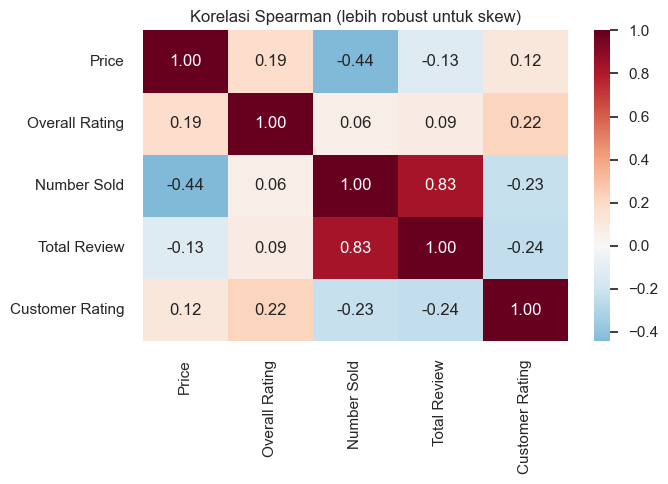

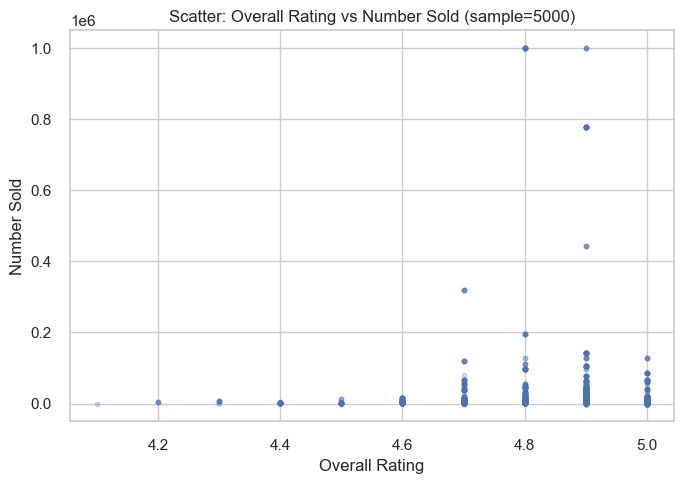

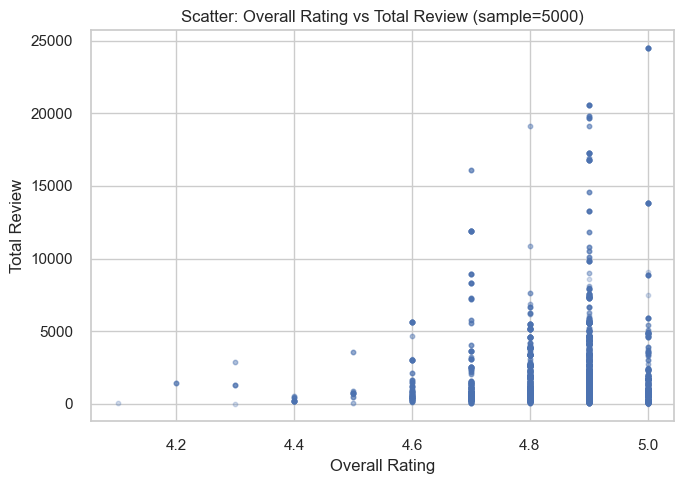

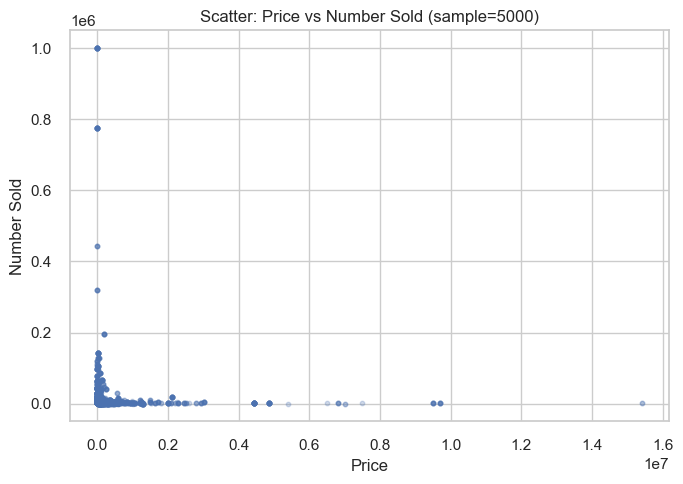

In [10]:
corr_cols = [c for c in ["Price", "Overall Rating", "Number Sold", "Total Review", "Customer Rating"] if c in df_clean.columns]

if len(corr_cols) >= 2:
    corr_pearson = df_clean[corr_cols].corr(method="pearson")
    corr_spearman = df_clean[corr_cols].corr(method="spearman")
    display(corr_pearson)
    display(corr_spearman)

    if HAS_SEABORN:
        plt.figure(figsize=(7, 5))
        sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
        plt.title("Korelasi Spearman (lebih robust untuk skew)")
        plt.tight_layout()
        plt.show()

# Scatter plots (sampling biar ringan)
plot_pairs = [
    ("Overall Rating", "Number Sold"),
    ("Overall Rating", "Total Review"),
    ("Price", "Number Sold"),
]

for x_col, y_col in plot_pairs:
    if x_col in df_clean.columns and y_col in df_clean.columns:
        tmp = df_clean[[x_col, y_col]].dropna()
        if len(tmp) > 5000:
            tmp = tmp.sample(5000, random_state=42)
        plt.figure(figsize=(7, 5))
        plt.scatter(tmp[x_col], tmp[y_col], alpha=0.25, s=10)
        plt.title(f"Scatter: {x_col} vs {y_col} (sample={len(tmp)})")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

## 10) Text EDA: Panjang Review, Tokenisasi, Stopwords (ID)
Catatan: dataset bisa berisi kata kasar/profanity. Notebook ini **tidak menampilkan review mentah secara masif**; untuk keyword kita bisa filter/skip term yang tidak ingin ditampilkan.

,count,mean,std,min,25%,50%,75%,max
review_char_len,5400.0,103.805741,98.256559,3.0,44.0,78.0,128.0,1058.0
review_word_len,5400.0,16.095000,15.647181,1.0,7.0,12.0,20.0,184.0


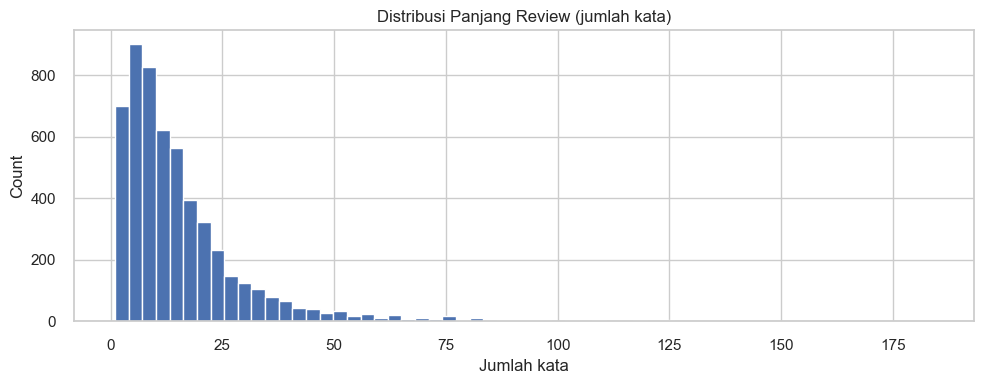

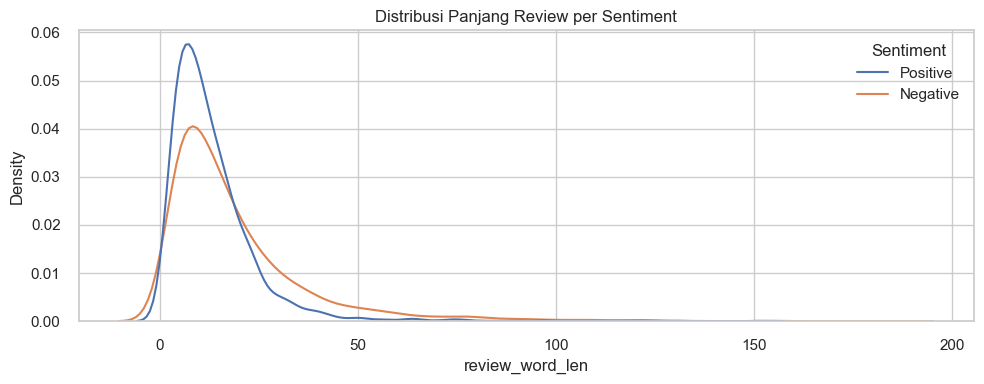

,token,count
0,barang,1493
1,yg,1182
2,sesuai,1100
3,bagus,882
4,cepat,781
5,pengiriman,671
6,beli,605
7,seller,546
8,produk,533
9,sangat,494


In [11]:
ID_STOPWORDS = {
    "yang","dan","di","ke","dari","ini","itu","untuk","dengan","pada","saya","aku","kamu",
    "nya","nya","ga","gak","nggak","tidak","ada","aja","sih","kok","banget","bgt","udah","sudah",
    "dgn","jg","juga","dpt","dapat","tdk","kl","kalau","kalo","dll","deh","lah","ya","yah",
    "tp","tapi","karena","krn","biar","bisa","jadi","sampe","sampai","pas","buat","dalam","lebih",
}

# Token yang tidak ingin ditampilkan (opsional; hanya untuk display, bukan mengubah data)
# Kamu bisa tambah/kurangi sesuai kebutuhan.
DISPLAY_BLOCKLIST = {"***"}

URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_ALNUM_RE = re.compile(r"[^a-z0-9\s]")


def clean_text_basic(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    # Normalisasi whitespace + hapus karakter selain alnum
    text = NON_ALNUM_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_id(text: str):
    text = clean_text_basic(text)
    tokens = [t for t in text.split() if len(t) >= 2]
    tokens = [t for t in tokens if t not in ID_STOPWORDS]
    return tokens


if "Customer Review" in df_clean.columns:
    df_clean["review_text"] = df_clean["Customer Review"].fillna("")
    df_clean["review_char_len"] = df_clean["review_text"].astype(str).str.len()
    df_clean["review_word_len"] = df_clean["review_text"].astype(str).str.split().map(len)
    df_clean["review_tokens"] = df_clean["review_text"].map(tokenize_id)

    display(df_clean[["review_char_len", "review_word_len"]].describe().T)

    # Distribusi panjang review
    plt.figure(figsize=(10, 4))
    plt.hist(df_clean["review_word_len"].dropna(), bins=60)
    plt.title("Distribusi Panjang Review (jumlah kata)")
    plt.xlabel("Jumlah kata")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    if HAS_SEABORN and "Sentiment" in df_clean.columns:
        plt.figure(figsize=(10, 4))
        sns.kdeplot(data=df_clean, x="review_word_len", hue="Sentiment", common_norm=False)
        plt.title("Distribusi Panjang Review per Sentiment")
        plt.tight_layout()
        plt.show()

    # Token paling sering (global)
    all_tokens = [t for toks in df_clean["review_tokens"] for t in toks]
    top_tokens = Counter(all_tokens).most_common(30)
    display(pd.DataFrame(top_tokens, columns=["token", "count"]))

## 11) Keyword & N-gram per Sentiment/Emotion (TF-IDF / CountVectorizer)
Bagian ini memakai `scikit-learn`. Kalau belum terpasang, cell akan memberi instruksi singkat.

,label,term,score
0,Negative,yg,0.035782
1,Negative,barang,0.031229
2,Negative,kecewa,0.024811
3,Negative,sesuai,0.020656
4,Negative,dikirim,0.020468
5,Negative,beli,0.019810
6,Negative,kurang,0.017729
7,Negative,lama,0.016562
8,Negative,rusak,0.015976
9,Negative,sama,0.014285


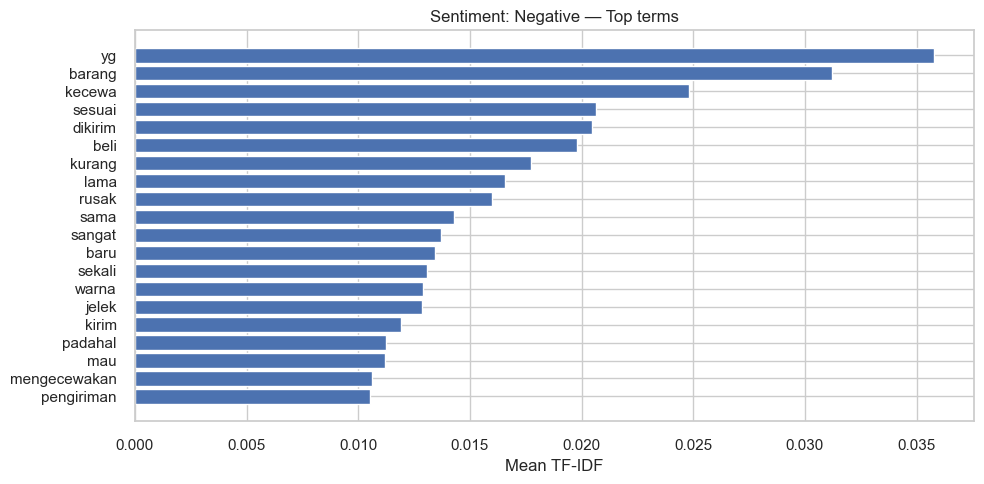

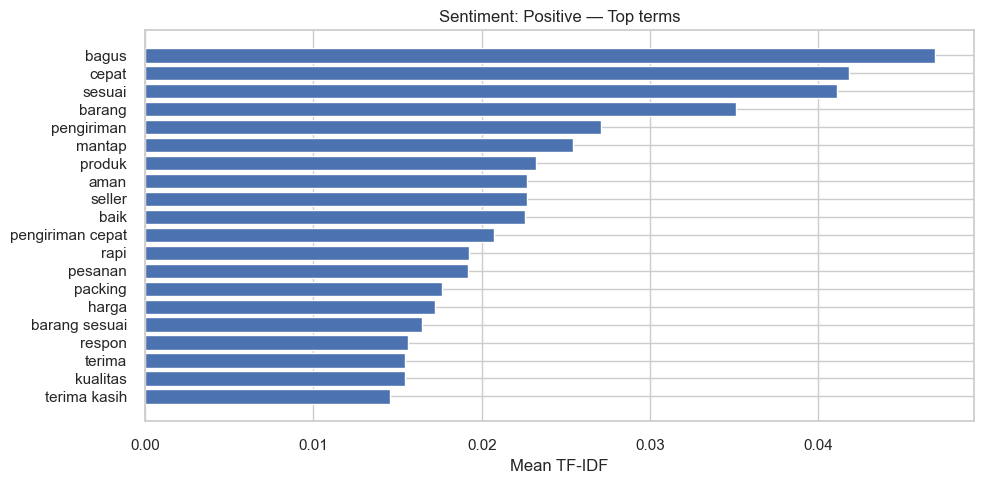

,label,term,score
0,Anger,barang,0.032625
1,Anger,jelek,0.032256
2,Anger,yg,0.031349
3,Anger,dikirim,0.026492
4,Anger,lama,0.026099
5,Anger,beli,0.021379
6,Anger,rusak,0.018754
7,Anger,parah,0.015245
8,Anger,pengiriman,0.014561
9,Anger,penjual,0.014389


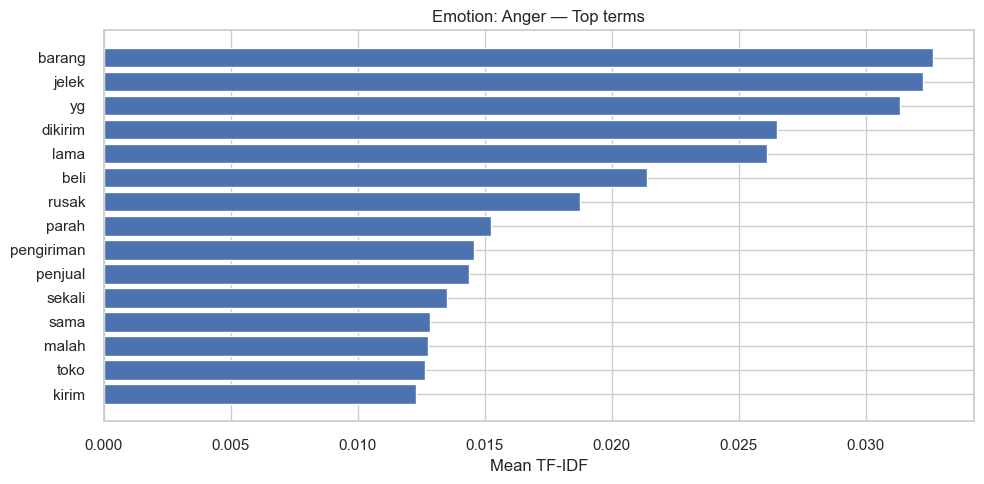

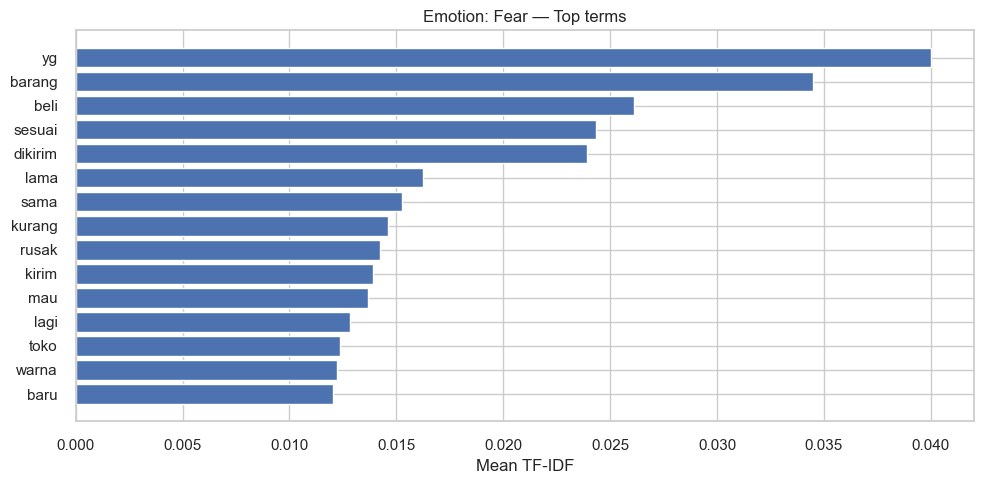

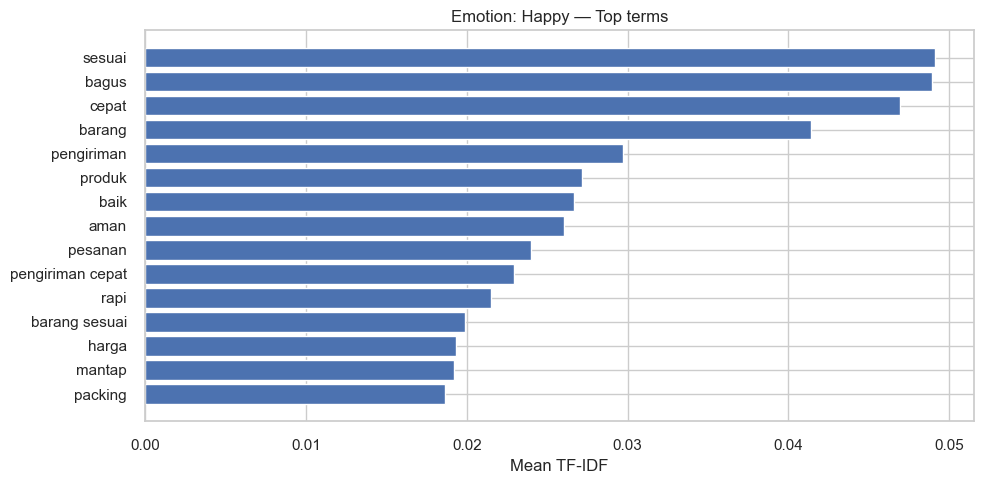

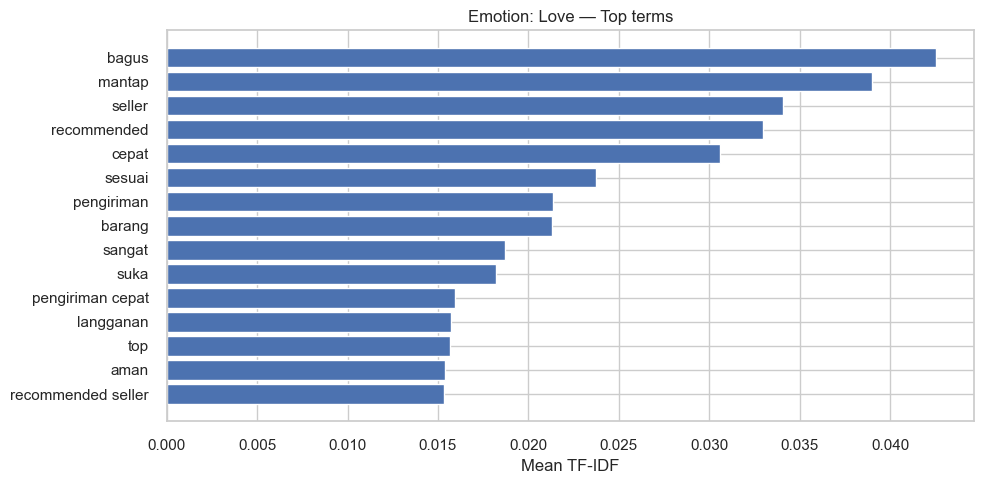

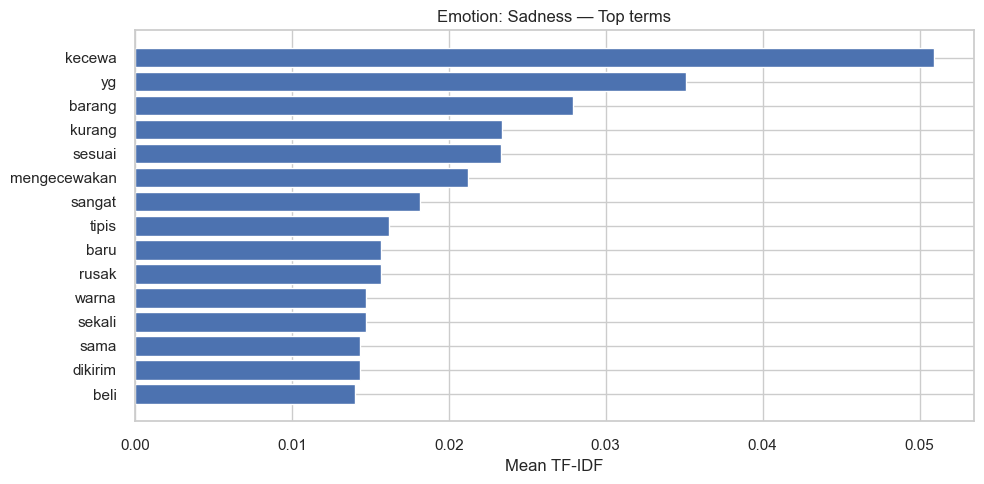

,term,chi2
492,cepat,589.768983
2664,yg,455.509884
184,bagus,408.339624
1169,kecewa,361.291270
102,aman,291.842854
1482,mantap,265.147494
655,dikirim,262.867836
2017,rapi,202.764610
2096,rusak,173.199877
1782,padahal,166.149593


In [12]:
def top_terms_by_label(df_in: pd.DataFrame, text_col: str, label_col: str, top_k: int = 20, ngram_range=(1, 2)):
    if not HAS_SKLEARN:
        print("scikit-learn belum tersedia. Install via: pip install scikit-learn")
        return

    df_tmp = df_in[[text_col, label_col]].dropna().copy()
    if df_tmp.empty:
        print("Data kosong untuk text/label.")
        return

    # Vectorizer: pakai tokenizer kita agar konsisten dengan stopword ID
    vec = TfidfVectorizer(
        tokenizer=tokenize_id,
        preprocessor=lambda x: x,
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=3,
        max_df=0.9,
    )

    X = vec.fit_transform(df_tmp[text_col].astype(str))
    y = df_tmp[label_col].astype(str)

    terms = np.array(vec.get_feature_names_out())

    # Rata-rata TF-IDF per label
    out = []
    for label in sorted(y.unique()):
        idx = (y == label).values
        if idx.sum() < 5:
            continue
        mean_tfidf = np.asarray(X[idx].mean(axis=0)).ravel()
        top_idx = mean_tfidf.argsort()[::-1][:top_k]
        for t, score in zip(terms[top_idx], mean_tfidf[top_idx]):
            out.append({"label": label, "term": t, "score": float(score)})

    res = pd.DataFrame(out)
    return res


def plot_top_terms(res: pd.DataFrame, label: str, top_k: int = 20, title_prefix: str = ""):
    sub = res[res["label"] == label].sort_values("score", ascending=False).head(top_k)
    if sub.empty:
        return
    plt.figure(figsize=(10, 5))
    plt.barh(sub["term"][::-1], sub["score"][::-1])
    plt.title(f"{title_prefix}{label} — Top terms")
    plt.xlabel("Mean TF-IDF")
    plt.tight_layout()
    plt.show()


if all(c in df_clean.columns for c in ["review_text", "Sentiment"]):
    res_sent = top_terms_by_label(df_clean, text_col="review_text", label_col="Sentiment", top_k=20, ngram_range=(1, 2))
    if res_sent is not None:
        display(res_sent.head(50))
        for lab in sorted(df_clean["Sentiment"].dropna().unique()):
            plot_top_terms(res_sent, lab, top_k=20, title_prefix="Sentiment: ")

if all(c in df_clean.columns for c in ["review_text", "Emotion"]):
    # Batasi hanya emotion yang cukup banyak supaya lebih stabil
    emo_counts = df_clean["Emotion"].value_counts()
    keep_emo = emo_counts[emo_counts >= 50].index
    df_emo = df_clean[df_clean["Emotion"].isin(keep_emo)].copy()
    res_emo = top_terms_by_label(df_emo, text_col="review_text", label_col="Emotion", top_k=15, ngram_range=(1, 2))
    if res_emo is not None:
        display(res_emo.head(50))
        for lab in sorted(df_emo["Emotion"].dropna().unique()):
            plot_top_terms(res_emo, lab, top_k=15, title_prefix="Emotion: ")

# (Opsional) chi-square untuk term penting pemisah label
if HAS_SKLEARN and all(c in df_clean.columns for c in ["review_text", "Sentiment"]):
    df_tmp = df_clean[["review_text", "Sentiment"]].dropna().copy()
    if df_tmp["Sentiment"].nunique() == 2 and len(df_tmp) >= 200:
        vec = CountVectorizer(tokenizer=tokenize_id, preprocessor=lambda x: x, token_pattern=None, min_df=3)
        X = vec.fit_transform(df_tmp["review_text"].astype(str))
        y = df_tmp["Sentiment"].astype(str)
        labels = sorted(y.unique())
        y_bin = (y == labels[1]).astype(int)
        chi2_scores, pvals = chi2(X, y_bin)
        terms = np.array(vec.get_feature_names_out())
        top = pd.DataFrame({"term": terms, "chi2": chi2_scores}).sort_values("chi2", ascending=False).head(30)
        display(top)

## 12) Ringkasan Insight (Pivot) + Export Dataset Bersih

In [13]:
# Pivot ringkas
if all(c in df_clean.columns for c in ["Sentiment", "Category", "Customer Rating"]):
    pivot1 = pd.pivot_table(
        df_clean,
        index="Category",
        columns="Sentiment",
        values="Customer Rating",
        aggfunc=["count", "mean", "median"],
        fill_value=0,
    )
    display(pivot1)

if all(c in df_clean.columns for c in ["Sentiment", "Emotion"]):
    pivot2 = pd.crosstab(df_clean["Emotion"], df_clean["Sentiment"], normalize="columns")
    display(pivot2)

# Assert sederhana (quality checks)
for c in ["Price", "Overall Rating", "Number Sold", "Total Review", "Customer Rating"]:
    if c in df_clean.columns:
        assert pd.api.types.is_numeric_dtype(df_clean[c]), f"Kolom {c} harus numeric"

for c in ["Sentiment", "Emotion"]:
    if c in df_clean.columns:
        assert df_clean[c].astype(str).str.len().gt(0).all(), f"Kolom {c} ada yang kosong"

# Export data bersih
OUT_PATH = "PRDECT-ID Dataset_clean.csv"
df_clean.to_csv(OUT_PATH, index=False, encoding="utf-8")
print("Exported:", OUT_PATH, "| shape:", df_clean.shape)

count               mean             median  \
Sentiment                Negative Positive  Negative  Positive Negative   
Category                                                                  
Animal Care                   120       80  1.233333  5.000000      1.0   
Automotive                    120       80  1.050000  5.000000      1.0   
Beauty                        100      100  2.130000  4.610000      2.0   
Body Care                     120       80  1.175000  5.000000      1.0   
Books                         100      100  2.150000  4.420000      2.0   
Camera                        101       99  1.930693  4.878788      2.0   
Carpentry                     120       80  1.200000  4.987500      1.0   
Computers and Laptops         120       80  1.050000  5.000000      1.0   
Electronics                   100      100  1.780000  4.580000      2.0   
Food and Drink                120       80  1.141667  5.000000      1.0   
Gaming                        100      100  1.850000  4.940000      2.0   
Health                        100      100  1.600000  4.920000      1.0   
Household                     100      100  1.850000  4.920000      2.0   
Kids and Baby Fashion         100      100  1.960000  4.560000      2.0   
Kitchen                       100      100  1.770000  4.560000      2.0   
Men's Fashion                 100      100  1.940000  4.800000      2.0   
Mother and Baby               100      100  1.470000  4.830000      1.0   
Movies and Music              100      100  1.450000  4.550000      1.0   
Muslim Fashion                100      100  1.760000  4.610000      2.0   
Office & Stationery           120       80  1.016667  5.000000      1.0   
Other Products                120       80  1.200000  4.975000      1.0   
Party Supplies and Craft      120       80  1.183333  5.000000      1.0   
Phones and Tablets            100      100  1.770000  4.500000      2.0   
Precious Metal                  0       80  0.000000  5.000000      0.0   
Property                        0       40  0.000000  5.000000      0.0   
Sport                         120       80  1.225000  5.000000      1.0   
Tour and Travel                 0       80  0.000000  5.000000      0.0   
Toys and Hobbies              120       80  1.141667  5.000000      1.0   
Women's Fashion               100      100  2.090000  4.440000      2.0   

                                   
Sentiment                Positive  
Category                           
Animal Care                   5.0  
Automotive                    5.0  
Beauty                        5.0  
Body Care                     5.0  
Books                         5.0  
Camera                        5.0  
Carpentry                     5.0  
Computers and Laptops         5.0  
Electronics                   5.0  
Food and Drink                5.0  
Gaming                        5.0  
Health                        5.0  
Household                     5.0  
Kids and Baby Fashion         5.0  
Kitchen                       5.0  
Men's Fashion                 5.0  
Mother and Baby               5.0  
Movies and Music              5.0  
Muslim Fashion                5.0  
Office & Stationery           5.0  
Other Products                5.0  
Party Supplies and Craft      5.0  
Phones and Tablets            5.0  
Precious Metal                5.0  
Property                      5.0  
Sport                         5.0  
Tour and Travel               5.0  
Toys and Hobbies              5.0  
Women's Fashion               5.0

Sentiment,Negative,Positive
Emotion,,
Anger,0.247784,0.000000
Fear,0.326125,0.000000
Happy,0.000000,0.686313
Love,0.000000,0.313687
Sadness,0.426090,0.000000


Exported: PRDECT-ID Dataset_clean.csv | shape: (5400, 16)
